# Previsão do Valor de Imóveis

Este notebook apresenta a solução para a tarefa prática de previsão do valor de imóveis com base em variáveis como localização, tamanho, número de quartos e idade. Utilizaremos técnicas de pré-processamento de dados e o modelo de Regressão Linear.

# Importações necessárias

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#Carregamento e leitura dos dados

In [ ]:
# Carregar os dados
imoveis = '/content/Tarefa1_real_estate_data.csv'
df=pd.read_csv(imoveis)

# Visualizandos os Dados

In [ ]:
# Visualizar os primeiros registros
display(df)

,Location,Size (m²),Bedrooms,Age (years),Price ($)
0,Zona Rural,229,4,36,346764
1,Centro,162,1,22,284286
2,Zona Rural,111,1,9,178148
3,Zona Rural,290,4,4,332703
4,Centro,235,1,35,405540
...,...,...,...,...,...
195,Subúrbio,270,3,5,119836
196,Zona Rural,95,4,43,154573
197,Zona Rural,166,1,44,479802
198,Subúrbio,55,2,31,308090


In [ ]:
# Contagem de dados nulos por coluna
df.isnull().sum()

,0
Location,0
Size (m²),0
Bedrooms,0
Age (years),0
Price ($),0


#Colunas atuais

In [ ]:
df.columns

Index(['Location', 'Size (m²)', 'Bedrooms', 'Age (years)', 'Price ($)'], dtype='object')

#Alterando o nome das colunas

In [ ]:
df.columns=['Location', 'Size', 'Bedrooms', 'Age', 'Price']

#Aplicação do Get Dummies

In [ ]:
dummies=pd.get_dummies(df.Location,prefix='imovel')
dummies

,imovel_Centro,imovel_Subúrbio,imovel_Zona Rural
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,True,False,False
...,...,...,...
195,False,True,False
196,False,False,True
197,False,False,True
198,False,True,False


#Atribuindo os valores transformados ao DF

In [ ]:
merged=pd.concat([df,dummies],axis=1)
merged

,Location,Size,Bedrooms,Age,Price,imovel_Centro,imovel_Subúrbio,imovel_Zona Rural
0,Zona Rural,229,4,36,346764,False,False,True
1,Centro,162,1,22,284286,True,False,False
2,Zona Rural,111,1,9,178148,False,False,True
3,Zona Rural,290,4,4,332703,False,False,True
4,Centro,235,1,35,405540,True,False,False
...,...,...,...,...,...,...,...,...
195,Subúrbio,270,3,5,119836,False,True,False
196,Zona Rural,95,4,43,154573,False,False,True
197,Zona Rural,166,1,44,479802,False,False,True
198,Subúrbio,55,2,31,308090,False,True,False


#Criando objeto para regressão linear

In [ ]:
from sklearn.linear_model import LinearRegression
modelo=LinearRegression()

#Separando features e classe

In [ ]:
X=df.drop(['Location', 'Price'],axis=1)
y=df.Price


X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True)

In [ ]:
X

,Size,Bedrooms,Age
0,229,4,36
1,162,1,22
2,111,1,9
3,290,4,4
4,235,1,35
...,...,...,...
195,270,3,5
196,95,4,43
197,166,1,44
198,55,2,31


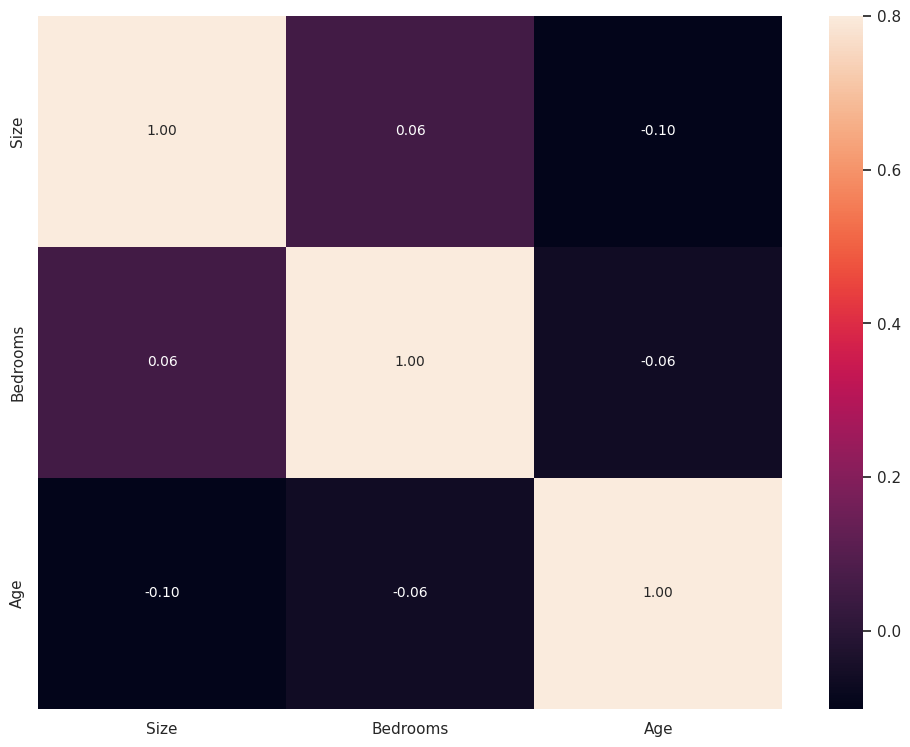

In [ ]:
corr = X.corr()
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
plt.subplots(figsize=(12, 9))
sns.heatmap(corr, vmax=.8,annot_kws={'size': 10}, annot=True, fmt='.2f');

In [ ]:
y

,Price
0,346764
1,284286
2,178148
3,332703
4,405540
...,...
195,119836
196,154573
197,479802
198,308090


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#Treinando o modelo

In [ ]:
model.fit(X,y)

LinearRegression()

#Teste

In [ ]:
# Permite que o usuário digite dados de um imovel e o modelo faça a predição do preço

# Function to predict price based on user input
def predict_price():
    location = input("Enter the location: ")
    size = float(input("Enter the size of the property: "))
    bedrooms = int(input("Enter the number of bedrooms: "))
    age = int(input("Enter the age of the property: "))

    # Create a DataFrame for the new data point
    new_data = pd.DataFrame({'size': [size], 'bedrooms': [bedrooms], 'age': [age]})

    # Apply One-Hot Encoding to the location for the new data point
    location_encoded = pd.get_dummies(pd.Series([location]))

    # Handle missing columns in the new data (align with training data columns)
    new_data = pd.concat([new_data, location_encoded], axis=1)
    new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

    # Make the price prediction
    predicted_price = model.predict(new_data)
    print("The predicted price is: ", predicted_price[0])


# Call the function to get user input and make the prediction
predict_price()

Enter the location: recanto
Enter the size of the property: 50
Enter the number of bedrooms: 3
Enter the age of the property: 100
The predicted price is:  325134.684052715
